# Faza 1 — originalni LipNet inference na GPU-u

Cilj: zvanični GRID demo video → stabilizovan `128×64` mouth ROI → VIPL unseen-speaker checkpoint → greedy CTC → CER/WER.

> `processed/` je srpski skup za Fazu 2/3 i ne koristi se kao ulaz engleskom checkpoint-u u ovoj fazi.

## 1. GPU i zavisnosti
Pre pokretanja izaberi **Runtime → Change runtime type → T4 GPU**.

In [ ]:
import subprocess
import sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'face-alignment==1.4.1', 'jiwer==3.1.0'], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'face-alignment==1.4.1', 'jiwer==3.1.0'], returncode=0)

In [2]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError('CUDA nije dostupna. Uključi T4 GPU: Runtime -> Change runtime type.')

DEVICE = torch.device('cuda')
print('PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU: Tesla T4


## 2. Preuzimanje checkpoint-a i legalnog GRID demo primera
Video i anotacija dolaze sa zvaničnog GRID sajta; checkpoint iz zvaničnog VIPL repozitorijuma.

In [3]:
from pathlib import Path
from urllib.request import urlretrieve

WORK_DIR = Path('/content/lipnet_faza1')
WORK_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_PATH = WORK_DIR / 'swwp2s.mpg'
ALIGN_PATH = WORK_DIR / 'swwp2s.align'
CHECKPOINT_PATH = WORK_DIR / 'LipNet_unseen.pt'

URLS = {
    VIDEO_PATH: 'https://spandh.dcs.shef.ac.uk/gridcorpus/examples/id2_vcd_swwp2s.mpg',
    ALIGN_PATH: 'https://spandh.dcs.shef.ac.uk/gridcorpus/examples/swwp2s.align',
    CHECKPOINT_PATH: ('https://raw.githubusercontent.com/'
        'VIPL-Audio-Visual-Speech-Understanding/LipNet-PyTorch/master/pretrain/'
        'LipNet_unseen_loss_0.44562849402427673_wer_0.1332580699113564_'
        'cer_0.06796452465503355.pt'),
}

for path, url in URLS.items():
    if not path.exists() or path.stat().st_size == 0:
        print('Preuzimam:', path.name)
        urlretrieve(url, path)
    print(f'{path.name}: {path.stat().st_size / 1024**2:.2f} MB')

Preuzimam: swwp2s.mpg
swwp2s.mpg: 0.38 MB
Preuzimam: swwp2s.align
swwp2s.align: 0.00 MB
Preuzimam: LipNet_unseen.pt
LipNet_unseen.pt: 25.33 MB


## 3. LipNet arhitektura kompatibilna sa VIPL težinama
Tri 3D konvoluciona bloka izdvajaju prostorno-vremenske osobine; dva dvosmerna GRU sloja modeluju celu sekvencu; linearni sloj daje 28 CTC klasa (blank + razmak + A–Z).

In [ ]:
import torch.nn as nn  # noqa: PLR0402


class LipNet(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        self.conv1 = nn.Conv3d(3, 32, (3, 5, 5), (1, 2, 2), (1, 2, 2))
        self.pool1 = nn.MaxPool3d((1, 2, 2), (1, 2, 2))
        self.conv2 = nn.Conv3d(32, 64, (3, 5, 5), 1, (1, 2, 2))
        self.pool2 = nn.MaxPool3d((1, 2, 2), (1, 2, 2))
        self.conv3 = nn.Conv3d(64, 96, (3, 3, 3), 1, (1, 1, 1))
        self.pool3 = nn.MaxPool3d((1, 2, 2), (1, 2, 2))
        self.gru1 = nn.GRU(96 * 4 * 8, 256, bidirectional=True)
        self.gru2 = nn.GRU(512, 256, bidirectional=True)
        self.FC = nn.Linear(512, 28)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout_p)
        self.dropout3d = nn.Dropout3d(dropout_p)

    def forward(self, x):
        x = self.pool1(self.dropout3d(self.relu(self.conv1(x))))
        x = self.pool2(self.dropout3d(self.relu(self.conv2(x))))
        x = self.pool3(self.dropout3d(self.relu(self.conv3(x))))
        x = x.permute(2, 0, 1, 3, 4).contiguous()
        x = x.view(x.size(0), x.size(1), -1)
        self.gru1.flatten_parameters()
        self.gru2.flatten_parameters()
        x, _ = self.gru1(x)
        x, _ = self.gru2(self.dropout(x))
        return self.FC(self.dropout(x)).permute(1, 0, 2).contiguous()

## 4. Dekodiranje videa, poravnanje lica i mouth crop
Ovo reprodukuje geometriju VIPL demo-a, ali koristi aktuelni `face-alignment` API i interpolira eventualno propuštene landmark-e umesto da izbaci frejm.

In [ ]:
import cv2
import face_alignment
import numpy as np


def canonical_landmarks(size=256, padding=0.25):
    x = np.array([0.000213256,0.0752622,0.18113,0.29077,0.393397,0.586856,0.689483,0.799124,0.904991,0.98004,0.490127,0.490127,0.490127,0.490127,0.36688,0.426036,0.490127,0.554217,0.613373,0.121737,0.187122,0.265825,0.334606,0.260918,0.182743,0.645647,0.714428,0.793132,0.858516,0.79751,0.719335,0.254149,0.340985,0.428858,0.490127,0.551395,0.639268,0.726104,0.642159,0.556721,0.490127,0.423532,0.338094,0.290379,0.428096,0.490127,0.552157,0.689874,0.553364,0.490127,0.42689])
    y = np.array([0.106454,0.038915,0.0187482,0.0344891,0.0773906,0.0773906,0.0344891,0.0187482,0.038915,0.106454,0.203352,0.307009,0.409805,0.515625,0.587326,0.609345,0.628106,0.609345,0.587326,0.216423,0.178758,0.179852,0.231733,0.245099,0.244077,0.231733,0.179852,0.178758,0.216423,0.244077,0.245099,0.780233,0.745405,0.727388,0.742578,0.727388,0.745405,0.780233,0.864805,0.902192,0.909281,0.902192,0.864805,0.784792,0.778746,0.785343,0.778746,0.784792,0.824182,0.831803,0.824182])
    return np.column_stack(((x + padding) / (2 * padding + 1) * size,
                            (y + padding) / (2 * padding + 1) * size)).astype(np.float32)

def similarity_transform(source, target):
    source = source.astype(np.float64)
    target = target.astype(np.float64)
    c1, c2 = source.mean(0), target.mean(0)
    p1, p2 = source - c1, target - c2
    s1, s2 = p1.std(), p2.std()
    p1, p2 = p1 / s1, p2 / s2
    u, _, vt = np.linalg.svd(p1.T @ p2)
    rotation = (u @ vt).T
    matrix = np.zeros((2, 3), dtype=np.float64)
    matrix[:, :2] = (s2 / s1) * rotation
    matrix[:, 2] = c2 - matrix[:, :2] @ c1
    return matrix

def read_frames(video_path):
    capture = cv2.VideoCapture(str(video_path))
    fps = capture.get(cv2.CAP_PROP_FPS)
    frames = []
    while True:
        ok, bgr = capture.read()
        if not ok:
            break
        # VIPL je treniran iz OpenCV BGR frejmova; konverzija u RGB radi se samo za landmark detektor/prikaz.
        frames.append(bgr)
    capture.release()
    if not frames:
        raise RuntimeError(f'Video nije moguće otvoriti: {video_path}')
    return frames, fps

def interpolate_landmarks(landmarks):
    valid = [i for i, value in enumerate(landmarks) if value is not None]
    if not valid:
        raise RuntimeError('Lice nije pronađeno ni na jednom frejmu.')
    flattened = np.full((len(landmarks), 136), np.nan, dtype=np.float32)
    for i in valid:
        flattened[i] = landmarks[i].reshape(-1)
    all_indices = np.arange(len(landmarks))
    for column in range(flattened.shape[1]):
        flattened[:, column] = np.interp(all_indices, valid, flattened[valid, column])
    return flattened.reshape(-1, 68, 2)

def make_mouth_tensor(video_path):
    frames, fps = read_frames(video_path)
    detector = face_alignment.FaceAlignment(
        face_alignment.LandmarksType.TWO_D, flip_input=False, device='cuda')
    detected = []
    for index, frame in enumerate(frames):
        result = detector.get_landmarks(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        detected.append(None if result is None else result[0][:, :2])
        if (index + 1) % 15 == 0 or index + 1 == len(frames):
            print(f'Landmarks: {index + 1}/{len(frames)} frejmova')
    detected = interpolate_landmarks(detected)
    target = canonical_landmarks()
    mouth_center = target[-20:].mean(0).astype(int)
    crops = []
    for frame, points in zip(frames, detected):
        affine = similarity_transform(points[17:], target)
        aligned = cv2.warpAffine(frame, affine, (256, 256))
        cx, cy = mouth_center
        crop = aligned[cy - 40:cy + 40, cx - 80:cx + 80]
        if crop.shape[:2] != (80, 160):
            raise RuntimeError(f'Neispravan mouth crop: {crop.shape}')
        crops.append(cv2.resize(crop, (128, 64), interpolation=cv2.INTER_LANCZOS4))
    array = np.stack(crops).astype(np.float32) / 255.0
    tensor = torch.from_numpy(array).permute(3, 0, 1, 2).unsqueeze(0)
    return tensor, array, frames, fps

video_tensor, mouth_crops, original_frames, source_fps = make_mouth_tensor(VIDEO_PATH)
print('Ulaz u model (B,C,T,H,W):', tuple(video_tensor.shape), 'FPS:', source_fps)

Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /root/.cache/torch/hub/checkpoints/s3fd-619a316812.pth


100%|██████████| 85.7M/85.7M [00:06<00:00, 14.5MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-cd938726ad.zip" to /root/.cache/torch/hub/checkpoints/2DFAN4-cd938726ad.zip
100%|██████████| 91.9M/91.9M [00:06<00:00, 16.0MB/s]


Landmarks: 15/75 frejmova
Landmarks: 30/75 frejmova
Landmarks: 45/75 frejmova
Landmarks: 60/75 frejmova
Landmarks: 75/75 frejmova
Ulaz u model (B,C,T,H,W): (1, 3, 75, 64, 128) FPS: 25.0


## 5. Učitavanje težina i inference

In [6]:
def load_checkpoint(model, checkpoint_path):
    try:
        state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    except TypeError:
        state = torch.load(checkpoint_path, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    state = {key.removeprefix('module.'): value for key, value in state.items()}
    incompat = model.load_state_dict(state, strict=True)
    print(f'Učitano {len(state)} tenzora; missing={incompat.missing_keys}, unexpected={incompat.unexpected_keys}')

ALPHABET = ' ABCDEFGHIJKLMNOPQRSTUVWXYZ'

def greedy_ctc_decode(logits):
    ids = logits.argmax(-1).squeeze(0).tolist()
    output, previous = [], None
    for token in ids:
        if token != previous and token != 0:
            output.append(ALPHABET[token - 1])
        previous = token
    return ''.join(output).strip()

model = LipNet().to(DEVICE)
load_checkpoint(model, CHECKPOINT_PATH)
model.eval()
with torch.inference_mode():
    logits = model(video_tensor.to(DEVICE))
prediction = greedy_ctc_decode(logits)
print('Logits (B,T,C):', tuple(logits.shape))
print('Predikcija:', prediction)

Učitano 24 tenzora; missing=[], unexpected=[]
Logits (B,T,C): (1, 75, 28)
Predikcija: SET WHITE WITH B TWO SOON


## 6. Ground truth, CER/WER i vizuelna provera ROI-a

Ground truth: SET WHITE WITH P TWO SOON
Predikcija  : SET WHITE WITH B TWO SOON
CER: 0.040
WER: 0.167


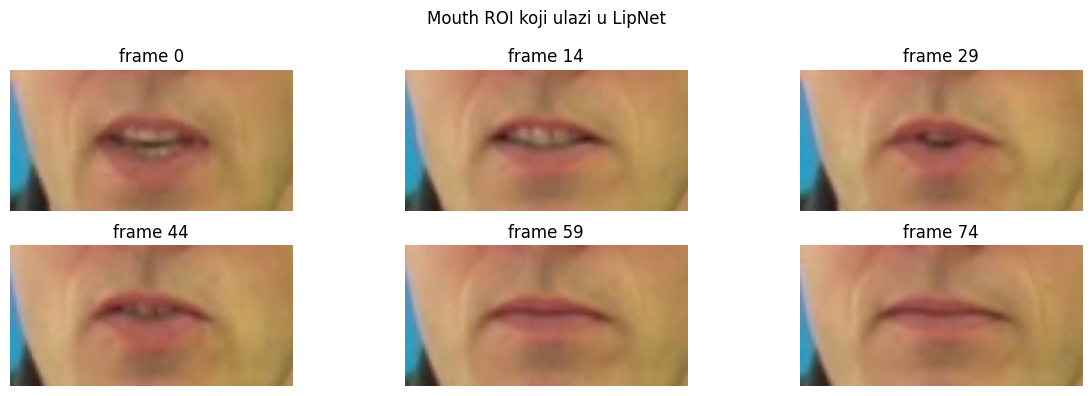

In [ ]:
import matplotlib.pyplot as plt
from jiwer import cer, wer


def read_grid_transcript(path):
    tokens = []
    for line in Path(path).read_text().splitlines():
        token = line.split()[-1]
        if token.lower() not in {'sil', 'sp'}:
            tokens.append(token)
    return ' '.join(tokens).upper()

ground_truth = read_grid_transcript(ALIGN_PATH)
print('Ground truth:', ground_truth)
print('Predikcija  :', prediction)
print(f'CER: {cer(ground_truth, prediction):.3f}')
print(f'WER: {wer(ground_truth, prediction):.3f}')

indices = np.linspace(0, len(mouth_crops) - 1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(12, 4))
for axis, index in zip(axes.flat, indices):
    axis.imshow(cv2.cvtColor((mouth_crops[index] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    axis.set_title(f'frame {index}')
    axis.axis('off')
plt.suptitle('Mouth ROI koji ulazi u LipNet')
plt.tight_layout()
plt.show()

In [ ]:
import json
import shutil
from pathlib import Path

import numpy as np
from google.colab import drive

drive.mount("/content/drive")

SAVE_ROOT = Path("/content/drive/MyDrive/LipNet")
CHECKPOINT_DIR = SAVE_ROOT / "checkpoints"
PHASE1_DIR = SAVE_ROOT / "phase1"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

# Predtrenirani model
shutil.copy2(
    CHECKPOINT_PATH,
    CHECKPOINT_DIR / "LipNet_unseen.pt"
)

# GRID demo ulazi
shutil.copy2(
    VIDEO_PATH,
    PHASE1_DIR / VIDEO_PATH.name
)
shutil.copy2(
    ALIGN_PATH,
    PHASE1_DIR / ALIGN_PATH.name
)

# Obrađeni ROI frejmovi usana
np.save(
    PHASE1_DIR / "mouth_crops.npy",
    mouth_crops
)

# Rezultat eksperimenta
result = {
    "phase": 1,
    "checkpoint": "LipNet_unseen.pt",
    "video": VIDEO_PATH.name,
    "ground_truth": ground_truth,
    "prediction": prediction,
    "cer": float(cer(ground_truth, prediction)),
    "wer": float(wer(ground_truth, prediction)),
    "input_shape": list(video_tensor.shape),
    "fps": float(source_fps),
    "gpu": torch.cuda.get_device_name(0),
    "pytorch_version": torch.__version__,
}

with open(PHASE1_DIR / "phase1_result.json", "w", encoding="utf-8") as file:
    json.dump(result, file, ensure_ascii=False, indent=2)

print("Sačuvano u:", SAVE_ROOT)

Mounted at /content/drive
Sačuvano u: /content/drive/MyDrive/LipNet


In [10]:
for path in sorted(SAVE_ROOT.rglob("*")):
    if path.is_file():
        print(f"{path.relative_to(SAVE_ROOT)} — {path.stat().st_size / 1024**2:.2f} MB")

checkpoints/LipNet_unseen.pt — 25.33 MB
phase1/mouth_crops.npy — 7.03 MB
phase1/phase1_result.json — 0.00 MB
phase1/swwp2s.align — 0.00 MB
phase1/swwp2s.mpg — 0.38 MB


## Kriterijum završetka Faze 1

Faza je završena kada: GPU je prepoznat, checkpoint je učitan bez missing/unexpected ključeva, oblik ulaza je `(1, 3, T, 64, 128)`, ROI slike prikazuju stabilne usne, a inference ispiše tekst, CER i WER.

Sledeća faza pravi manifest, speaker-disjoint split i mouth ROI za srpski `processed/`.